<a href="https://colab.research.google.com/github/ShamScripts/Employee-Attrition-RF-Model/blob/main/01_Random_Forest_Attrition_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee attrition — Random Forest  
### Predict turnover with **Random Forest**; compare **logistic regression** and **decision tree** on IBM HR data

**Class imbalance:** attrition is rare; we weight models and stress F1/recall—not accuracy alone.

**How to run:** execute all cells **top to bottom** from the project folder (same folder as `ibm_hr_attrition.csv` and `plots/`).

---

### In this notebook

1. How **Random Forest** relates to **logistic regression** and a single **decision tree**.  
2. A full workflow: **data → preprocess → train → evaluate → interpret**.  
3. **Train vs test** accuracy, **confusion matrices**, **ROC/AUC**, **feature importance**.  
4. **Predicted probabilities** as an attrition **risk score**.

---

### Table of contents

| Section | Content |
|---------|---------|
| **1 · Introduction** | Goal: teach Random Forest; attrition as illustration |
| **2 · Dataset overview** | Load IBM data, quick exploration |
| **3 · Data preprocessing** | Cleaning, encoding, train/test split |
| **4 · Concepts** | LR limits, tree overfitting, RF: bagging, random features, voting |
| **5 · Logistic regression (baseline)** | Linear benchmark |
| **6 · Decision tree (baseline)** | Nonlinear rules; **overfitting** (train ≫ test) |
| **7 · Random Forest (main model)** | Ensemble; **diagram** + sample **trees** |
| **8 · Model evaluation** | Metrics, **confusion matrices**, ROC |
| **9 · Feature importance** | Plot + plain-language interpretation |
| **10 · Comparison** | DT vs RF (and LR): **accuracy** bars |
| **11 · Attrition risk score** | Probabilities, not only labels |
| **12 · What-if analysis** | Change one input (e.g. overtime) |
| **13 · Conclusion** | Takeaways, limitations, references |

---


## 1 · Introduction

Random Forest is the main character of this notebook: an ensemble that grows many decision trees on **bootstrap** samples of employees, injects randomness into **which features** each split may use, and then **votes**. That recipe usually tames the wild variance of a single deep tree—the kind of tree that memorizes the training sheet and then stumbles on new rows.

We use IBM-style attrition data as a **concrete illustration**, not because HR is the only use case. The same pipeline applies wherever you have tabular features and a binary outcome. Alongside the forest we keep a **logistic regression** line (linear, fast, calibrated probabilities under some assumptions) and a **deliberately overfit** decision tree so the contrast in behavior is visible on the same train/test split.

- **Logistic regression** — a transparent linear baseline.  
- **Decision tree** — flexible rules; our deep variant will highlight overfitting.  
- **Random Forest** — the ensemble that typically trades individual tree noise for stabler test performance.

---


## 2 · Dataset overview

We load `ibm_hr_attrition.csv`, check shape and dtypes, and optionally subsample for quick demos. Before any modeling, notice the **class balance**: leavers are the minority, which will later pull metrics and justify **class-weighted** learners. Features span demographics, role, pay, satisfaction, and tenure—mixed types that motivate one-hot encoding and tree-based models that handle nonlinearities without manual interaction terms.


In [1]:
# One-line install (quiet) for Colab or fresh environments. Skip if packages are already present.
%pip install -q -r requirements.txt


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
# --- Setup: imports, paths, reproducibility ---
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import FancyBboxPatch

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
)
from sklearn.feature_selection import f_classif

# Interactive ROC is optional (keeps the notebook usable without holoviews/bokeh)
try:
    import holoviews as hv
    import hvplot.pandas
    hv.extension("bokeh")
    HAS_HVPLOT = True
except ImportError:
    HAS_HVPLOT = False

ROOT = Path.cwd()
if not (ROOT / "ibm_hr_attrition.csv").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "ibm_hr_attrition.csv"
PLOTS_DIR = ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Attrition"
RANDOM_STATE = 42
USE_SMALL_SAMPLE = False   # set True for ~500-row stratified demo
SAMPLE_N = 500

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

print("Dataset path:", DATA_PATH.resolve())
print("hvplot/holoviews available:", HAS_HVPLOT)


Dataset path: /content/ibm_hr_attrition.csv
hvplot/holoviews available: False


With libraries loaded, we pull the CSV into memory. The IBM HR attrition file is row-level: each record is one employee snapshot, and the label `Attrition` is heavily skewed toward “No.” Seeing the raw table first grounds everything that follows—encoding choices, metrics, and why accuracy alone is a weak guide.


A quick `info()` pass confirms dtypes and non-null counts before we split variables into numeric versus categorical buckets. That distinction matters because trees treat ordered integers differently from nominal strings, and our preprocessing step will one-hot encode the latter.


In [3]:
# Load data; optional stratified subsample for weak machines / short class periods
df_raw = pd.read_csv(DATA_PATH)

if USE_SMALL_SAMPLE and len(df_raw) > SAMPLE_N:
    df_raw, _ = train_test_split(
        df_raw, train_size=SAMPLE_N, stratify=df_raw[TARGET], random_state=RANDOM_STATE
    )
    df_raw = df_raw.reset_index(drop=True)
    print(f"[Demo mode] Using n = {len(df_raw)} rows (stratified).")
else:
    print(f"Using full sample: n = {len(df_raw)} rows.")

print("Shape (rows, columns):", df_raw.shape)
df_raw.head()


Using full sample: n = 1470 rows.
Shape (rows, columns): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Quick variable lists (numeric vs categorical) — informs preprocessing
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numeric columns:", len(num_cols), "| Categorical:", len(cat_cols))


Numeric columns: 26 | Categorical: 9


These figures ask three questions the model will later try to approximate: how rare leavers are, whether age and income separate stayers from leavers, and whether overtime coincides with higher churn rates. The overlaps are messy—that nonlinear messiness is partly why a linear baseline and a single deep tree behave so differently from an ensemble.


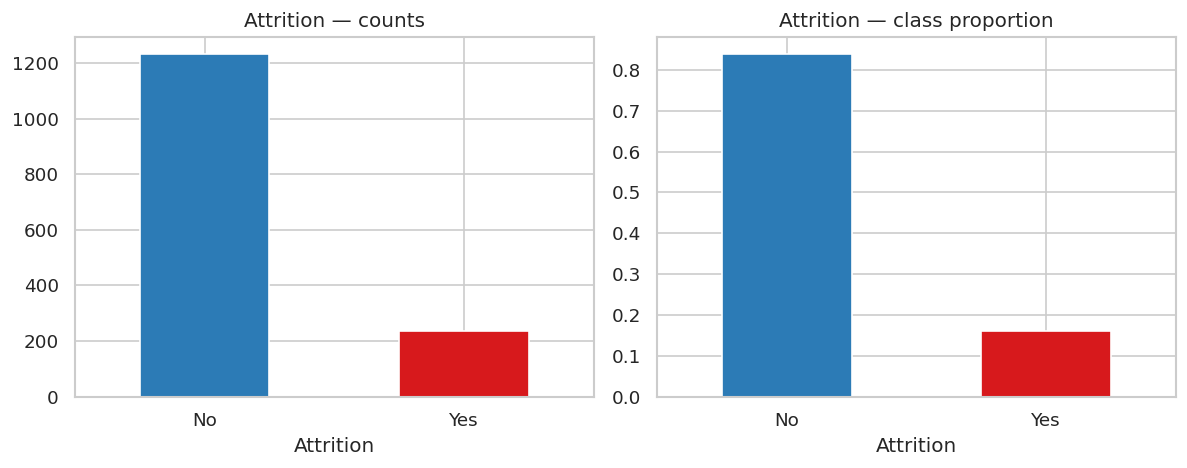

In [ ]:
# Exploratory plots: class balance and two relationships
df_eda = df_raw.copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_eda[TARGET].value_counts().plot(kind="bar", ax=axes[0], color=["#2c7bb6", "#d7191c"], rot=0)
axes[0].set_title("Attrition — counts")
df_eda[TARGET].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color=["#2c7bb6", "#d7191c"], rot=0)
axes[1].set_title("Attrition — class proportion")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_eda_balance.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
if "Age" in df_eda.columns:
    sns.boxplot(data=df_eda, x=TARGET, y="Age", ax=axes[0], palette=["#2c7bb6", "#d7191c"])
    axes[0].set_title("Age vs attrition")
if "MonthlyIncome" in df_eda.columns:
    sns.kdeplot(data=df_eda, x="MonthlyIncome", hue=TARGET, common_norm=False, ax=axes[1])
    axes[1].set_title("Monthly income vs attrition")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_eda_age_income.png", bbox_inches="tight")
plt.show()

if "OverTime" in df_eda.columns:
    ct = pd.crosstab(df_eda["OverTime"], df_eda[TARGET], normalize="index") * 100
    ct.plot(kind="bar", figsize=(6, 4), color=["#2c7bb6", "#d7191c"], rot=0)
    plt.ylabel("Percent within overtime group")
    plt.title("Attrition % by overtime")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fig_eda_overtime.png", bbox_inches="tight")
    plt.show()


The class bars make the imbalance visible: most rows are “No,” so a naive model could score well on accuracy while almost never flagging someone who will leave. That is why we later emphasize precision, recall, and F1 for the minority class, and why we reweight the loss with `class_weight`. The age and income plots suggest separation is partial at best—consistent with weak linear separability and with the value of tree ensembles that allow thresholds and interactions.


### EDA — closing takeaways

- **Prevalence:** attrition is a minority event; evaluation metrics must reflect that.
- **Signals:** overtime and compensation-adjacent patterns often show up as shifts in distributions—useful hypotheses for HR, not proof of causation.
- **Modeling implication:** stratified splitting keeps the churn rate stable across train and test; class weighting keeps learners from defaulting to “always stay.”


## 3 · Data preprocessing

Rows with missing values are dropped (this file is usually complete; production pipelines would impute). Identifiers and constants go away so they cannot dominate splits. `Attrition` becomes 0/1; categoricals are **one-hot encoded** with `drop_first=True` to avoid redundant dummies. The train/test split is **stratified** on `y` so the churn rate stays comparable across sets—critical when positives are scarce.


In [ ]:
# Cleaning: drop NA; remove uninformative columns (IBM attrition standard)
df = df_raw.copy().dropna()
DROP = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=[c for c in DROP if c in df.columns], errors="ignore")
print("Shape after cleaning:", df.shape)

# Target: Yes -> 1, No -> 0
y = (df[TARGET].astype(str).str.strip() == "Yes").astype(int)
X = df.drop(columns=[TARGET])
X = pd.get_dummies(X, drop_first=True)

print("Encoded feature matrix:", X.shape)
print("Positive class rate (left company):", round(y.mean(), 4))


In [ ]:
# Stratified split: same churn rate approximately in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean(), 4), "| Test:", round(y_test.mean(), 4))


## 4 · Concepts — why Random Forest?

### Limitations of logistic regression (for this problem)

Logistic regression assumes a **linear** relationship between features and the **log-odds** of leaving. It is fast and interpretable, but **real HR processes** are often **nonlinear** (interactions, thresholds). LR is our **linear baseline**, not the “truth.”

### Why a single decision tree can overfit

A decision tree asks a sequence of yes/no questions until it reaches a **leaf** prediction. A **deep** tree can **memorize** training noise: **training accuracy** looks excellent, but **test accuracy** drops. That **gap** is the classic sign of **overfitting** (low bias, high variance on small/noisy regions).

**Analogy:** one expert who has **memorized** past cases but **does not generalize** to new employees.

### What is Random Forest?

**Random Forest** trains **many** decision trees on **different bootstrap samples** of rows (**bagging**). At each split, only a **random subset of features** is considered (**random feature selection**). For a new employee, each tree votes; the forest takes the **majority vote** (**aggregation**).

**Analogies:**

- **Bagging:** different study groups each review a **random resample** of past employees.  
- **Random features:** each group is **not allowed** to look at all variables at once — forces **diversity** of trees.  
- **Voting:** the **wisdom of the crowd** — wrong trees partly cancel out; **variance** often drops vs one tree.

**Reference:** L. Breiman (2001), *Random Forests*, Machine Learning.

---

### Worked micro-example (Gini impurity)

Consider a parent node with 10 employees: 6 stay, 4 leave. The Gini impurity is  
\(G = 1 - (0.6^2 + 0.4^2) = 0.48\).  
Suppose a split on overtime yields a left child (5 stay, 1 leave) and a right child (1 stay, 3 leave). Their Ginis are about 0.278 and 0.375; weighted by group size, the children’s impurity drops to roughly 0.32. The **decrease** (0.48 − 0.32) is what the tree maximizes (along with other splits). sklearn automates this search across all features and thresholds—this hand calculation simply shows **what** is being optimized.

### Variance in plain terms

A deep tree has **low bias** on training data but **high variance**: small perturbations to the sample change the tree structure a lot. Random Forest **averages** many trees trained on **different** bootstrap samples and **different** feature subsets at each split, so individual trees’ mistakes are **less correlated**—the ensemble’s prediction is stabler on held-out data (often smaller train–test gap than one memorizing tree).


## 5 · Logistic regression (baseline)

Logistic regression is our **linear** benchmark: it estimates log-odds as a weighted sum of inputs (after scaling, so one-hot columns and z-scored numerics live on comparable scales). It trains quickly and calibrates reasonably well when the decision boundary is roughly monotone, but it cannot invent interaction terms unless we engineer them. We set `class_weight="balanced"` so the optimizer does not treat the majority “stay” class as the only thing worth getting right—especially important when accuracy would look fine even if every employee were predicted to stay.


In [ ]:
# Logistic regression with scaling; balanced weights counteract class imbalance in the loss
model_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )),
])
model_lr.fit(X_train, y_train)

acc_lr_tr = accuracy_score(y_train, model_lr.predict(X_train))
acc_lr_te = accuracy_score(y_test, model_lr.predict(X_test))
p_lr = precision_score(y_test, model_lr.predict(X_test), pos_label=1, zero_division=0)
r_lr = recall_score(y_test, model_lr.predict(X_test), pos_label=1, zero_division=0)
f1_lr = f1_score(y_test, model_lr.predict(X_test), pos_label=1, zero_division=0)
print("Logistic Regression — train accuracy:", round(acc_lr_tr, 4))
print("Logistic Regression — test  accuracy:", round(acc_lr_te, 4))
print("  (minority class) precision / recall / F1:", round(p_lr, 4), round(r_lr, 4), round(f1_lr, 4))


## 6 · Decision tree (baseline) — overfitting in action

Here we deliberately fit a **very flexible** tree (`max_depth=None`, `min_samples_leaf=1`) so you can **see** overfitting rather than read about it abstractly. Training accuracy will hug 1.0 while test accuracy lags—classic high-variance behavior. We still pass `class_weight="balanced"` so the tree does not trivially predict “stay” for everyone; the point of the section is the **gap**, not a production-ready tree. Random Forest, introduced next, targets exactly this instability by averaging many weaker learners.


In [ ]:
# Deep tree: memorizes training structure; class_weight helps minority-class splits
model_dt = DecisionTreeClassifier(
    max_depth=None,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)
model_dt.fit(X_train, y_train)

pred_dt_tr = model_dt.predict(X_train)
pred_dt_te = model_dt.predict(X_test)
acc_dt_tr = accuracy_score(y_train, pred_dt_tr)
acc_dt_te = accuracy_score(y_test, pred_dt_te)

print("Decision Tree — train accuracy:", round(acc_dt_tr, 4))
print("Decision Tree — test  accuracy:", round(acc_dt_te, 4))
print("Train − test gap (overfitting signal):", round(acc_dt_tr - acc_dt_te, 4))


## 7 · Random Forest (main model)

This is the algorithmic centerpiece: many trees, each grown on a bootstrap sample, each split considering only a random subset of features. The forest averages votes, which **dampens** the variance that made the deep tree swing so wildly between train and test. We use `class_weight="balanced_subsample"` so class frequencies are reweighted **per tree**—a good default for skewed attrition labels alongside `n_estimators` trees.


In [ ]:
# Random Forest: ensemble of trees (bootstrap + random splits + majority vote)
N_TREES = 150
model_rf = RandomForestClassifier(
    n_estimators=N_TREES,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=1,
)
model_rf.fit(X_train, y_train)

# Retain an untuned snapshot for the hyperparameter section
rf_untuned = model_rf

pred_rf_tr = model_rf.predict(X_train)
pred_rf_te = model_rf.predict(X_test)
acc_rf_tr = accuracy_score(y_train, pred_rf_tr)
acc_rf_te = accuracy_score(y_test, pred_rf_te)

print("Random Forest — train accuracy:", round(acc_rf_tr, 4))
print("Random Forest — test  accuracy:", round(acc_rf_te, 4))
print("Train − test gap:", round(acc_rf_tr - acc_rf_te, 4))


In [ ]:
# Visual: Random Forest flow — data -> many trees -> majority vote -> prediction
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4.5)
ax.axis("off")
ax.text(5, 4.1, "Random Forest: many trees → majority vote", ha="center", fontsize=12, fontweight="bold")

ax.add_patch(FancyBboxPatch((0.2, 1.5), 1.3, 1.0, boxstyle="round,pad=0.05", fc="#e8f4fc", ec="#333"))
ax.text(0.85, 2.0, "Bootstrap\nsamples", ha="center", va="center", fontsize=9)

xs = [2.4, 3.5, 4.6, 5.7]
for i, x in enumerate(xs):
    ax.add_patch(FancyBboxPatch((x, 1.55), 0.85, 0.9, boxstyle="round,pad=0.02", fc="#fff8e7", ec="#333"))
    ax.text(x + 0.42, 2.0, f"Tree\n{i+1}", ha="center", va="center", fontsize=8)

ax.add_patch(FancyBboxPatch((7.1, 1.55), 1.2, 0.9, boxstyle="round,pad=0.02", fc="#e8f8e8", ec="#333"))
ax.text(7.7, 2.0, "Majority\nvote", ha="center", va="center", fontsize=9)

for x in xs:
    ax.annotate("", xy=(x + 0.42, 2.0), xytext=(0.85, 2.0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.1))
    ax.annotate("", xy=(7.7, 2.0), xytext=(x + 0.85, 2.0),
                arrowprops=dict(arrowstyle="->", color="gray", lw=1.0))

ax.text(5, 0.45, "Flow: input features → each tree predicts class → forest aggregates by voting.",
        ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_rf_diagram.png", bbox_inches="tight")
plt.show()

print("ASCII sketch:  features  →  [Tree 1 … Tree %d]  →  vote  →  Stay/Leave" % N_TREES)


In [ ]:
# Sample three different trees from the forest (depth capped) — one figure per tree for clarity
N_SHOW = min(3, len(model_rf.estimators_))
for i in range(N_SHOW):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    plot_tree(
        model_rf.estimators_[i],
        max_depth=3,
        feature_names=list(X.columns),
        class_names=["Stay", "Leave"],
        filled=True,
        rounded=True,
        fontsize=6,
        ax=ax,
    )
    ax.set_title("Random Forest — estimator %d (depth shown <= 3)" % (i + 1))
    fig.suptitle(
        "Different bootstrap samples and splits produce different trees",
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    out = PLOTS_DIR / ("fig_rf_sample_tree_%d.png" % (i + 1))
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())


### 7.1 Hyperparameter search (Random Forest)

Default settings are fine for pedagogy, but we can often eke out better **F1 on the minority class** with a modest search. `RandomizedSearchCV` samples a few dozen hyperparameter combinations with stratified folds—cheaper than a full grid when the space is large. We keep the **same** train/test split for reporting; cross-validation only ranks candidates inside the training set. The winner becomes our main `model_rf` for later sections, while `rf_untuned` stays available for a direct before/after comparison.


In [ ]:
# Randomized search on training data only; refit best estimator on full train
param_dist = {
    "n_estimators": [150, 200, 300],
    "max_depth": [None, 12, 20, 28],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.4, 0.6],
}

search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=0,
)
search.fit(X_train, y_train)
model_rf = search.best_estimator_

pred_rf_tr = model_rf.predict(X_train)
pred_rf_te = model_rf.predict(X_test)
print("Best CV F1 (mean):", round(search.best_score_, 4))
print("Best params:", search.best_params_)

f1_un = f1_score(y_test, rf_untuned.predict(X_test), pos_label=1, zero_division=0)
f1_tu = f1_score(y_test, pred_rf_te, pos_label=1, zero_division=0)
print("Test F1 (leave) — untuned RF:", round(f1_un, 4), "| tuned RF:", round(f1_tu, 4))


If F1 moves upward, the search found a better bias–variance tradeoff for this split; if the gain is tiny, the untuned forest was already near a good operating point—common on small tabular datasets. Either outcome is worth reporting honestly.


## 8 · Model evaluation

With predictions on the held-out test set, accuracy is reported **second**. The priority is how well each model handles the **leave** class: precision (trust when we flag someone), recall (how many true leavers we catch), and F1 (their harmonic balance). Confusion matrices make errors concrete; ROC curves summarize ranking quality across thresholds—useful when HR adjusts how aggressively to intervene.


In [ ]:
# Dictionary of fitted models for uniform evaluation (same held-out test for all)
models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
}

def metrics_row(name, model):
    pred = model.predict(X_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_leave": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall_leave": recall_score(y_test, pred, pos_label=1, zero_division=0),
        "f1_leave": f1_score(y_test, pred, pos_label=1, zero_division=0),
    }

metrics_table = pd.DataFrame([metrics_row(n, m) for n, m in models.items()])
metrics_table


The table often shows **accuracy** staying high even when recall on “leave” is modest—that is exactly the imbalance phenomenon. Comparing **F1** across the three models tells you which learner best balances false alarms and missed leavers for this snapshot; Random Forest frequently leads, but not always. Use the confusion matrices next to see *where* mistakes concentrate.


In [ ]:
# Confusion matrices (test set) — heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_cm = [["Pred stay", "Pred leave"], ["True stay", "True leave"]]
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels_cm[0], yticklabels=labels_cm[1])
    ax.set_title(name)
plt.suptitle("Confusion matrices — held-out test data", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_confusion_matrices.png", bbox_inches="tight")
plt.show()


Off-diagonal mass matters: top-right counts are **false alarms** (predicted leave, actually stayed); bottom-left are **missed leavers**. HR workflows differ in which error is costlier—screening for outreach often prefers recall, while budgeted interventions may demand higher precision. Those tradeoffs are threshold choices on predicted probabilities, not properties of accuracy alone.


In [ ]:
for name, model in models.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, model.predict(X_test), target_names=["Stay", "Leave"], zero_division=0))


In [ ]:
# ROC curves and AUC (test set)
roc_list = []
plt.figure(figsize=(7, 6))
for name, model in models.items():
    p1 = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, p1)
    a = auc(fpr, tpr)
    roc_list.append(pd.DataFrame({"fpr": fpr, "tpr": tpr, "model": name}))
    plt.plot(fpr, tpr, lw=2, label="%s (AUC = %.3f)" % (name, a))

plt.plot([0, 1], [0, 1], "k--", alpha=0.35)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves — test set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_roc.png", bbox_inches="tight")
plt.show()

roc_df = pd.concat(roc_list, ignore_index=True)
if HAS_HVPLOT:
    roc_df.hvplot.line(
        x="fpr", y="tpr", by="model", width=680, height=480,
        xlabel="False positive rate", ylabel="True positive rate",
        title="ROC (interactive)",
        legend="bottom",
    )
else:
    print("(Interactive hvplot skipped — holoviews/hvplot not installed.)")


## 9 · Feature importance (Random Forest)

Importance scores aggregate how much each feature contributed to **impurity reduction** across all splits in all trees. They are excellent for **storytelling**—which variables the model leaned on—but they are **not** causal effects: HR policies, unobserved stressors, and historical bias can all lurk behind an association. Correlated features **share** importance; a variable can rank low yet still matter in combination. Always pair these rankings with domain sense and ethics review before acting on individuals.


In [ ]:
# Random Forest: Gini-based feature importance (sklearn default)
importance_series = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_k = importance_series.head(18)

fig, ax = plt.subplots(figsize=(9, 6))
top_k.sort_values().plot(kind="barh", ax=ax, color="#1a9850")
ax.set_title("Random Forest — feature importance (top 18)")
ax.set_xlabel("Importance (Gini decrease, aggregated over trees)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_feature_importance.png", bbox_inches="tight")
plt.show()

# Top features by importance (for interpretation — not causal)
print("Top 8 features (highest importance scores):")
for feat, val in importance_series.head(8).items():
    print("  %-40s  %.4f" % (feat, val))


**Interpretation:** Higher scores mean the feature participated in more **useful** splits across the forest—again, **association**, not causation. If “overtime” ranks high, investigate workload policy with qualitative data; if income ranks high, consider equity reviews. Translate importances into **hypotheses** and **experiments**, not automatic HR actions.


## 10 · Comparison — Decision Tree vs Random Forest (and logistic regression)

Side-by-side bars make the **generalization story** visible: the deep tree’s train bar can touch 1.0 while test lags; the forest typically narrows that gap. Logistic regression often sits in between—worse than a flexibly split tree on training fit, but sometimes competitive on test if the signal is roughly linear. Read these charts together with the F1 column from the table above rather than in isolation.


In [ ]:
# Accuracy comparison: test set + train vs test bars
test_acc = {name: accuracy_score(y_test, m.predict(X_test)) for name, m in models.items()}
train_acc = {name: accuracy_score(y_train, m.predict(X_train)) for name, m in models.items()}

compare_df = pd.DataFrame({
    "train": [train_acc["Logistic Regression"], train_acc["Decision Tree"], train_acc["Random Forest"]],
    "test": [test_acc["Logistic Regression"], test_acc["Decision Tree"], test_acc["Random Forest"]],
}, index=["Logistic Regression", "Decision Tree", "Random Forest"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = compare_df["test"].plot(kind="bar", ax=axes[0], color=["#4a90d9", "#fdae61", "#2ca25f"], rot=15)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Test set accuracy — model comparison")
axes[0].set_ylim(0, 1.05)

compare_df.plot(kind="bar", ax=axes[1], color=["#4a90d9", "#e66101"], rot=15)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train vs test — overfitting vs generalization")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_accuracy_comparison.png", bbox_inches="tight")
plt.show()

compare_df.round(4)


### Modeling comparison — short summary

- **Linear baseline (LR):** stable, interpretable coefficients after scaling; may miss interactions the trees discover.
- **Deep tree:** exposes overfitting explicitly—large train–test split.
- **Random Forest + tuning:** aims for **variance reduction** and better minority-class behavior; the hyperparameter pass above is the honest “second pass” most applied projects run.


## 11 · Attrition risk score (predicted probability)

Hard labels throw away information. The forest’s **predicted probability** of leaving is a **risk score**: it ranks employees for follow-up conversations, cohort analyses, or threshold experiments. It is **not** a causal “if we pay more, probability drops” statement—calibration and ethics review still apply before any individual decision.


In [ ]:
# Attrition risk score = P(attrition = 1 | x) from Random Forest
risk_score_test = model_rf.predict_proba(X_test)[:, 1]

example_df = pd.DataFrame({
    "actual_left": y_test.values,
    "risk_score": np.round(risk_score_test, 4),
}).head(12)
example_df


In [ ]:
# Distribution of risk scores by true label
plt.figure(figsize=(7, 4))
plt.hist(risk_score_test[y_test == 0], bins=22, alpha=0.55, label="Actually stayed", color="#2c7bb6")
plt.hist(risk_score_test[y_test == 1], bins=22, alpha=0.55, label="Actually left", color="#d7191c")
plt.xlabel("Random Forest P(leave) — attrition risk score")
plt.ylabel("Count")
plt.title("Distribution of predicted leave probabilities (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "fig_risk_score_distribution.png", bbox_inches="tight")
plt.show()


## 12 · What-if analysis (bonus)

Flipping a single dummy such as overtime **holding all else fixed** shows **local sensitivity** of the learned function: how much the score moves when one input toggles. That is useful for stress-testing the model and for discussion with HR. It remains an **associative** counterfactual—real interventions change many correlated variables at once.


In [ ]:
# What-if: toggle overtime-related column if it exists after get_dummies
row = X_test.iloc[[0]].copy()
base_prob = model_rf.predict_proba(row)[0, 1]

# Common encodings: OverTime_Yes, or Overtime_Yes — match any column containing OverTime
ot_cols = [c for c in row.columns if "OverTime" in c or "Overtime" in c]
print("Baseline P(leave) for first test row:", round(base_prob, 4))
print("Overtime-related columns found:", ot_cols)

if ot_cols:
    row_whatif = row.copy()
    for c in ot_cols:
        # Flip 0/1 to simulate changing overtime status
        row_whatif[c] = 1.0 - row_whatif[c]
    new_prob = model_rf.predict_proba(row_whatif)[0, 1]
    print("After flipping overtime indicator(s):", round(new_prob, 4))
    print("Delta:", round(new_prob - base_prob, 4))
else:
    # Fallback: nudge first numeric column slightly
    num_cols_row = row.select_dtypes(include=[np.number]).columns
    if len(num_cols_row):
        c0 = num_cols_row[0]
        row_alt = row.copy()
        row_alt[c0] = row_alt[c0] * 1.1
        print("No OverTime column — nudging first numeric feature:", c0)
        print("P(leave) after +10% on", c0, ":", round(model_rf.predict_proba(row_alt)[0, 1], 4))


## 13 · Conclusion

### Takeaways

1. **Random Forest** aggregates **bootstrap-trained** trees with **random feature subsets** at splits, then votes—usually **lower variance** than one deep tree and strong **ranking** behavior on tabular HR data.  
2. **Class imbalance** makes accuracy misleading; **balanced class weights**, **F1 / recall / precision**, and **ROC** tell a fairer story for the minority “leave” class.  
3. **Hyperparameter search** can lift F1 modestly; report both tuned and untuned results for transparency.  
4. **Feature importances** and **risk scores** support **discussion**, not automatic policy: association **≠** causation.

### Fairness and responsible use

People analytics models can **encode historical bias** (who was promoted, who was labeled “high potential”). **Proxy variables**—zip code, commute, overtime correlated with caregiving—can create **disparate impact** on protected groups even when sensitive attributes are removed. Models should **inform** human decisions alongside governance: documentation, appeal paths, and monitoring for drift. They must **not** automate punitive actions or replace managerial judgment.

### Limitations

- **Observational** data — causal claims require design, not algorithms alone.  
- **Deployment** needs calibration checks, bias/fairness review, and **MLOps** monitoring.  
- **Scores** are statistical associations on a snapshot dataset.

### References

1. L. Breiman (2001). *Random Forests.* Machine Learning 45:5–32.  
2. F. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR.  
3. IBM HR Analytics Employee Attrition (educational dataset).

---

**End of notebook.**
